#Dataset Assessment and Initial Exploratory Analysis

**Author:** Stella Dong

*Department of Computer Science & Engineering, Texas A&M University*  
*This work was completed as part of CSCE 676: Data Mining and Analysis, taught by Prof. James Caverlee.*

The Github repository of this project can be found here: [Github link](https://github.com/stellasdong/676_project/).

---


In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')
path = "/content/drive/MyDrive/TAMU/data_mining/project_data"
os.chdir(path)

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from itertools import combinations


## Identification of Candidate Datasets

### Dataset 1: [Texas Inpatient PUF](https://www.dshs.texas.gov/center-health-statistics/texas-health-care-information-collection/download-and-purchase-data/texas-inpatient-public-use-data-file-pudf/public-use-data-File-pudf-inpatient-free-download)

This is a publicly available dataset of inpatient data across around 700 hospitals in Texas. Although it is completely anonymized, the dataset still contains hospital data, discharge data, diagnoses, stay durations, etc., that makes this dataset very rich. Course topics that this dataset align with include frequent itemsets and clustering, and beyond the course there is potential for sequence analysis or probabilistic record linkage. This dataset covers four quarters of hospital data, with 167 variables for around 800,000 records per quarter. There is a variety of data types for the variables, including address data, record IDs, temporal data, billing and charge data, and diagnosis codes. My target variable would likely be principal diagnosis code. Because this is anonymized health data, I am not permitted to use this dataset to link to other personally identifiable records or in anyway attempt to identify patients or physicians.


### Dataset 2: [NC Voter Registry Snapshot - Orange County](https://www.ncsbe.gov/results-data/voter-registration-data)

This is a subset of the North Carolina Voter Registration Data, isolated to just Orange County. Course topics that this data could align with is clustering to link households and large-scale ML to predict party affiliation. Beyond course techniques, this dataset could be used for temporal analysis, using the voter registration across multiple years to analyze shifts in party affiliation. The dataset includes a lot of variables, mostly strings, of addresses, personal information like name, gender and age, anonymized contact information, and their registered party code, which would be my target variable.
There are no limits to the usage of this dataset.

### Dataset 3: [CMS Health Insurance Exchange Rate PUF](https://download.cms.gov/marketplace-puf/2026/rate-puf.zip)

This is a dataset released by the CMS containing plan-level data on rates based on different factors for an eligible subscriber, like tobacco use, age and location. Course topics that this dataset could align with is large-scale ML to train a regression model to predict individual rate, clustering by region to find hidden high-cost zones, anomaly detection and streams. Beyond course techniques, this dataset lends itself well to surcharge strategy analysis to calculate any tobacco premium on insurance rates. The dataset has 25 variables for over 2 million rates. There's a large variety of data types, including IDs for the issuer and the plan, the rate, geographic data for where the plan is available and qualifying data on the subscriber, like their age and tobacco usage. The target variable for this dataset would be the rate. There are no limits to the usage of this dataset.

## Comparative Analysis of Datasets

| Dataset | Supported Tasks | Data Qual Issues | Alg. Feasibility | Bias | Ethics |
| :--- | :--- | :--- |  :--- | :--- | :--- |
| Texas Inpatient | frequent itemsets (course), <br>sequence analysis (external) | lagging in reporting causing repeats across quarters, missing values and invalid codes, anonymization causes a lot of noise | large amount of data across all of Texas for even just one quarter of 2019 | data reflects who accessed care, not who needed it, so findings can only be applied to those with healthcare access | risk of reidentification by performing analysis on this data that could expose patients |
| NC VR | clustering (course),<br> large-scale ML (course), <br> temporal analysis (external) | high volume of missing data for variables, including target variable: registered party code | Orange County is small enough for most ML algorithms without Spark, though expanding to other counties would need it | only one county is not representative of even the state, so biased towards Orange County, which is demographically different from surrounding counties due to UNC | analyzing party shifts at a household level can feel invasive |
| CMS Rates | large-scale ML (course), <br> surcharge strategy analysis (external) | missing variable data, mapping requires external datasets | a simple regression would be feasible on millions of rows, but more complex ML would need more memory | plans exclude states with their own platforms, which would cause bias in the national average | surcharge analysis could unintentionally highlight ways for issuers to maximize costs for vulnerable groups |



In [4]:
# NC Voter Registry
nc_voter = pd.read_csv("ncvoter68.txt", sep='\t',encoding='latin1')
nc_voter.info()

/tmp/ipython-input-2104579783.py:2: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  nc_voter = pd.read_csv("ncvoter68.txt", sep='\t',encoding='latin1')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140524 entries, 0 to 140523
Data columns (total 70 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   county_id                 140524 non-null  int64  
 1   county_desc               140524 non-null  object 
 2   voter_reg_num             140524 non-null  int64  
 3   ncid                      140524 non-null  object 
 4   last_name                 140517 non-null  object 
 5   first_name                140520 non-null  object 
 6   middle_name               126052 non-null  object 
 7   name_suffix_lbl           4783 non-null    object 
 8   status_cd                 140524 non-null  object 
 9   voter_status_desc         140524 non-null  object 
 10  reason_cd                 140524 non-null  object 
 11  voter_status_reason_desc  140524 non-null  object 
 12  res_street_address        140524 non-null  object 
 13  res_city_desc             114959 non-null  o

In [5]:
# CMS RATES PUF
rate_puf = pd.read_csv("rate-puf.csv")
rate_puf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2235761 entries, 0 to 2235760
Data columns (total 20 columns):
 #   Column                                     Dtype  
---  ------                                     -----  
 0   BusinessYear                               int64  
 1   StateCode                                  object 
 2   IssuerId                                   int64  
 3   SourceName                                 object 
 4   ImportDate                                 object 
 5   RateEffectiveDate                          object 
 6   RateExpirationDate                         object 
 7   PlanId                                     object 
 8   RatingAreaId                               object 
 9   Tobacco                                    object 
 10  Age                                        object 
 11  IndividualRate                             float64
 12  IndividualTobaccoRate                      float64
 13  Couple                                    

In [6]:
# TEXAS INPATIENT DATA
tx_inpatient_q1 = pd.read_csv("pudf/PUDF_base1_1q2019_tab.txt", sep="\t")
tx_inpatient_q2 = pd.read_csv("pudf/PUDF_base1_2q2019_tab.txt", sep="\t")
tx_inpatient_q3 = pd.read_csv("pudf/PUDF_base1_3q2019_tab.txt", sep="\t")
tx_inpatient_q4 = pd.read_csv("pudf/PUDF_base1_4q2019_tab.txt", sep="\t")

tx_inpatient = pd.DataFrame(np.concatenate([
    tx_inpatient_q1.values,
    tx_inpatient_q2.values,
    tx_inpatient_q3.values,
    tx_inpatient_q4.values]),
    columns=tx_inpatient_q1.columns
)
tx_inpatient.info()

/tmp/ipython-input-1336798860.py:2: DtypeWarning: Columns (4,6,7,11,15,17,18,21,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,103,105,107,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,128,130,132,134,136,138,140,142,144,146,148,150) have mixed types. Specify dtype option on import or set low_memory=False.
  tx_inpatient_q1 = pd.read_csv("pudf/PUDF_base1_1q2019_tab.txt", sep="\t")
/tmp/ipython-input-1336798860.py:3: DtypeWarning: Columns (4,6,7,11,15,17,18,21,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,103,105,107,122,124,126,128,130,132,134,136,138,140,142,144,146,148,150) have mixed types. Specify dtype option on import or set low_memory=False.
  tx_inpatient_q2 = pd.read_csv("pudf/PUDF_base1_2q2019_tab.txt", sep="\t")
/tmp/ipython-input-1336798860.py:4: DtypeWarning: Columns (4,6,7,11,15,17,18,21,68,69,70,71,72,73,74,75,76,77,78,79,80,81,87,88,89,90,91,92,93,94

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3141275 entries, 0 to 3141274
Columns: 168 entries, RECORD_ID to Unnamed: 167
dtypes: object(168)
memory usage: 3.9+ GB


In [7]:
# TEXAS INPATIENT DATA exclusive to Bryan-College Station facilities
BCS_THCIC_ID = ["975162", "975270", "717500", "002001", "206100", "975403", "976329"]
tx_inpatient['THCIC_ID'] = tx_inpatient['THCIC_ID'].astype(str)
bcs_tx_inpatient = tx_inpatient[tx_inpatient['THCIC_ID'].isin(BCS_THCIC_ID)]
bcs_tx_inpatient.info()

bcs_tx_inpatient.to_csv("bcs_tx_inpatient.csv")

<class 'pandas.core.frame.DataFrame'>
Index: 11174 entries, 34302 to 3040051
Columns: 168 entries, RECORD_ID to Unnamed: 167
dtypes: object(168)
memory usage: 14.4+ MB


## Dataset Selection

The dataset that I eventually decided on is the Texas Inpatient Dataset. I found that this dataset was the richest in variety of variables, so there are more opportunities to explore different analyses. Primarily, I chose this dataset because it supports finding frequent itemsets for common groups of diagnoses in patients. It also supports clustering for similar patients, then large-scale ML to predict a variety of variables, like length of stay, total charges, etc. External from coursework, this would support sequential analysis, to predict returns to hospitals based on features like diagnoses.

The trade-offs for this dataset is that this dataset requires linking to other datasets for important information about the facilities and the costs. There is also limited opportunities for any regression modeling, because a majority of the variables are nominal data. It is also a very large dataset, but I was able to circumvent this problem by first scaling the dataset down from the entire state (4GB mem) to just Bryan-College Station facilities (14.4 MB mem), and if time permits, I will scale my analyses up to a larger area.

## Exploratory Data Analysis

### Summary Statistics of Dataset

In [8]:
# preview of dataset
print("Number of rows: "+str(bcs_tx_inpatient.shape[0]))
print("Number of columns: "+str(bcs_tx_inpatient.shape[1]))
bcs_tx_inpatient.head()

Number of rows: 11174
Number of columns: 168


,RECORD_ID,DISCHARGE,THCIC_ID,TYPE_OF_ADMISSION,SOURCE_OF_ADMISSION,SPEC_UNIT_1,SPEC_UNIT_2,SPEC_UNIT_3,SPEC_UNIT_4,SPEC_UNIT_5,...,RISK_MORTALITY,ILLNESS_SEVERITY,APR_GROUPER_VERSION_NBR,APR_GROUPER_ERROR_CODE,ATTENDING_PHYSICIAN_UNIF_ID,OPERATING_PHYSICIAN_UNIF_ID,ENCOUNTER_INDICATOR,PROVIDER_NAME,EMERGENCY_DEPT_FLAG,Unnamed: 167
34302,120190072500,2019Q1,717500,3.0,1,NaN,NaN,NaN,NaN,NaN,...,1,1,7360,0,1770795465,1770795465.0,1,Physicians Centre Hospital,N,NaN
34303,120190072501,2019Q1,717500,3.0,1,NaN,NaN,NaN,NaN,NaN,...,1,1,7360,0,1770795465,1770795465.0,1,Physicians Centre Hospital,N,NaN
34304,120190072502,2019Q1,717500,3.0,1,NaN,NaN,NaN,NaN,NaN,...,1,1,7360,0,1770795465,1770795465.0,1,Physicians Centre Hospital,N,NaN
34305,120190072503,2019Q1,717500,3.0,1,NaN,NaN,NaN,NaN,NaN,...,1,2,7360,0,1770795465,1770795465.0,1,Physicians Centre Hospital,N,NaN
34306,120190072504,2019Q1,717500,3.0,1,NaN,NaN,NaN,NaN,NaN,...,1,1,7360,0,1770795465,1770795465.0,1,Physicians Centre Hospital,N,NaN


This gives me a preview of the dataset in the table. It also helps serve as a sanity check that the dataset imported properly, specifically with the headings.

In [9]:
# percentage missing for each variable
missing_summary = pd.DataFrame({
    'Column': bcs_tx_inpatient.columns,
    'Missing_Count': bcs_tx_inpatient.isnull().sum(),
    'Missing_Percentage': (bcs_tx_inpatient.isnull().sum() / len(bcs_tx_inpatient) * 100)
})
missing_summary.sort_values('Missing_Count')

,Column,Missing_Count,Missing_Percentage
RECORD_ID,RECORD_ID,0,0.0
DISCHARGE,DISCHARGE,0,0.0
THCIC_ID,THCIC_ID,0,0.0
TYPE_OF_ADMISSION,TYPE_OF_ADMISSION,0,0.0
SOURCE_OF_ADMISSION,SOURCE_OF_ADMISSION,0,0.0
...,...,...,...
POA_E_CODE_10,POA_E_CODE_10,11174,100.0
E_CODE_9,E_CODE_9,11174,100.0
POA_E_CODE_9,POA_E_CODE_9,11174,100.0
E_CODE_7,E_CODE_7,11174,100.0


I knew that because this is a real-world dataset, there would be a large amount of missing information. This gives me a very clear idea of what data is missing and isn't. I know I can rely on the record information to be present, like the ID, the discharge code, the admission type, and patient demographic information. The cost information is also always present, if that is something I decide to explore later, as well as the diagnoses information.

### Patient Population Demographics

In [10]:
# description of the population of patients
print("Age distribution:")
print(bcs_tx_inpatient['PAT_AGE'].value_counts())

print("\nSex distribution:")
print(bcs_tx_inpatient['SEX_CODE'].value_counts())

print("\nRace distribution:")
print(bcs_tx_inpatient['RACE'].value_counts())

Age distribution:
PAT_AGE
0     1554
17     984
18     942
16     894
19     828
15     729
20     644
8      624
14     572
9      561
7      449
21     436
13     376
10     359
24     262
12     246
11     191
23     143
25     107
6       82
1       67
26      54
2       24
3       20
5       17
4        9
Name: count, dtype: int64

Sex distribution:
SEX_CODE
F    6285
M    4323
Name: count, dtype: int64

Race distribution:
RACE
4    8546
3    1652
5     853
2     123
Name: count, dtype: int64


The cell above describes the distribution of the patients' demographics. This gives me a good idea of what the population looks at, and for later analysis can help me apply my findings to the real world population of these Bryan-College Station patients.

These tables below are from the dataset's data dictionary to help clarify what these representations signify.


Code indicating the patient's race.
| Code | Race |
|------|------|
|1|American Indian/Eskimo/Aleut|
|2|Asian or Pacific Islander|
|3|Black|
|4|White|
|5|Other|
|`|Invalid|

Code indicating age of patient in days or years on date of discharge.  
| Code | Age Range / Category | Code | Age Range / Category |
|------|----------------------|------|----------------------|
| 00 | 1–28 days | 11 | 40–44 |
| 01 | 29–365 days | 12 | 45–49 |
| 02 | 1–4 years | 13 | 50–54 |
| 03 | 5–9 | 14 | 55–59 |
| 04 | 10–14 | 15 | 60–64 |
| 05 | 15–17 | 16 | 65–69 |
| 06 | 18–19 | 17 | 70–74 |
| 07 | 20–24 | 18 | 75–79 |
| 08 | 25–29 | 19 | 80–84 |
| 09 | 30–34 | 20 | 85–89 |
| 10 | 35–39 | 21 | 90+ |

 HIV and Drug/Alcohol Use Patients
| Code | Age Range |
|------|-----------|
| 22 | 0–17 |
| 23 | 18–44 |
| 24 | 45–64 |
| 25 | 65–74 |
| 26 | 75+ |


### Payment Statistics

In [11]:
print("\nFirst Payment Source Distribution:")
print(bcs_tx_inpatient['FIRST_PAYMENT_SRC'].value_counts())



First Payment Source Distribution:
FIRST_PAYMENT_SRC
MA    3898
12    3283
CI    1439
MC    1081
ZZ     634
16     310
BL     270
HM     210
VA      21
CH      15
11       5
WC       4
OF       2
15       1
Name: count, dtype: int64


Similar to above, these are the code representations for the patients' payment sources.

| Code | Description | Code | Description |
|------|-------------|------|-------------|
| 09 | Self Pay *(Removed from 5010 format, use “ZZ” beginning 2Q2012 data)* | HM | Health Maintenance Organization |
| 10 | Central Certification | LI | Liability |
| 11 | Other Non-federal Programs | LM | Liability Medical |
| 12 | Preferred Provider Organization (PPO) | MA | Medicare Part A |
| 13 | Point of Service (POS) | MB | Medicare Part B |
| 14 | Exclusive Provider Organization (EPO) | MC | Medicaid |
| 15 | Indemnity Insurance | TV | Title V |
| 16 | Health Maintenance Organization (HMO) Medicare Risk | OF | Other Federal Program |
| AM | Automobile Medical | VA | Veteran Administration Plan |
| BL | Blue Cross/Blue Shield | WC | Workers Compensation Health Claim |
| CH | CHAMPUS | ZZ | Charity, Indigent or Unknown |
| CI | Commercial Insurance | `` | Codes 09 and ZZ, combined for 2004 & 2005 |
| DS | Disability Insurance |




### Diagnoses Distributions

Basket Size (Diagnosis Count) Statistics:
count    11174.000000
mean        12.569715
std          6.907886
min          1.000000
25%          6.000000
50%         12.000000
75%         18.000000
max         25.000000
Name: diagnosis_count, dtype: float64

Mode: 24
Median: 12.0

Diagnosis count distribution:
diagnosis_count
1       46
2      226
3      684
4      694
5      600
6      568
7      537
8      532
9      517
10     509
11     446
12     505
13     475
14     469
15     462
16     474
17     403
18     401
19     355
20     295
21     284
22     268
23     185
24    1063
25     176
Name: count, dtype: int64

Percentiles:
10th percentile: 4
25th percentile: 6
50th percentile: 12
75th percentile: 18
90th percentile: 24
95th percentile: 24
99th percentile: 25

Single diagnosis encounters: 46 (0.41%)
Multiple diagnoses encounters: 11128 (99.59%)


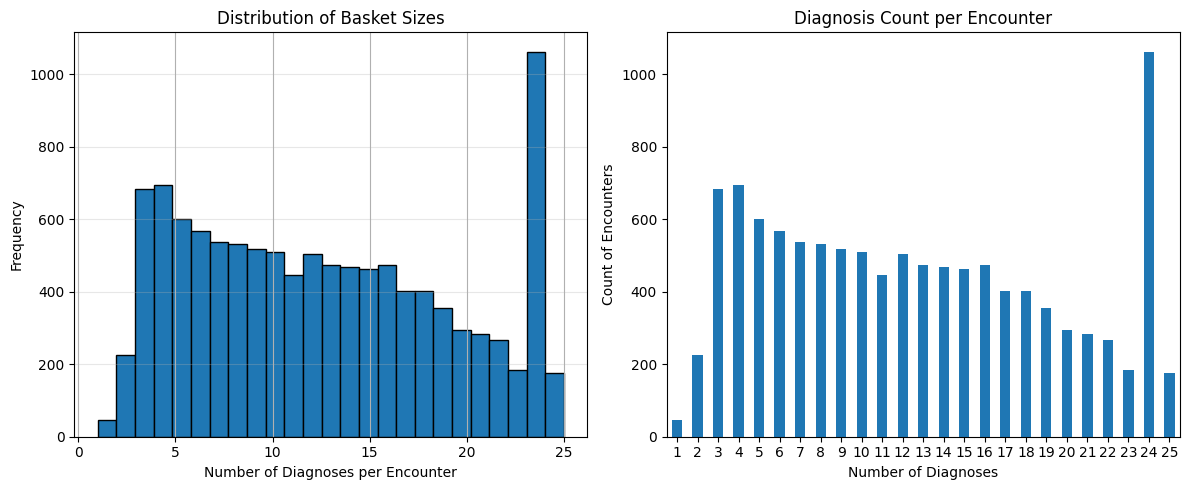

In [12]:
df = bcs_tx_inpatient.copy()

# Counting the number of diagnoses per encounter
diagnosis_cols = ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]
existing_diag_cols = [col for col in diagnosis_cols if col in df.columns]

df['diagnosis_count'] = df[existing_diag_cols].notna().sum(axis=1)

# statistics and distribution
print("Basket Size (Diagnosis Count) Statistics:")
print(df['diagnosis_count'].describe())
print(f"\nMode: {df['diagnosis_count'].mode()[0]}")
print(f"Median: {df['diagnosis_count'].median()}")

print("\nDiagnosis count distribution:")
print(df['diagnosis_count'].value_counts().sort_index())

percentiles = [10, 25, 50, 75, 90, 95, 99]
print("\nPercentiles:")
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(df['diagnosis_count'], p):.0f}")

single_diag = (df['diagnosis_count'] == 1).sum()
multiple_diag = (df['diagnosis_count'] > 1).sum()
print(f"\nSingle diagnosis encounters: {single_diag} ({single_diag/len(df)*100:.2f}%)")
print(f"Multiple diagnoses encounters: {multiple_diag} ({multiple_diag/len(df)*100:.2f}%)")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['diagnosis_count'].hist(bins=25, edgecolor='black')
plt.xlabel('Number of Diagnoses per Encounter')
plt.ylabel('Frequency')
plt.title('Distribution of Basket Sizes')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df['diagnosis_count'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Count of Encounters')
plt.title('Diagnosis Count per Encounter')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('basket_size_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

These two visualizations show the same distribution: the number of diagnosis codes recorded per patient encounter. The distribution reveals a right-skewed pattern with most encounters having 3-4 diagnoses. There's a gradual decline in frequency as diagnosis counts increase, with a notable spike at 25 diagnoses representing encounters that reached the maximum capacity of the dataset's diagnosis fields (PRINC_DIAG_CODE plus OTH_DIAG_CODE_1 through OTH_DIAG_CODE_24). This anomalous behavior suggests that there is a high amount of encounters had complex cases requiring documentation of the full allowable diagnosis set, indicating potential data truncation for highly complex patient cases. Or, this is an error that I will need to manually review in the future.

In [13]:
# collect all diagnosis codes
all_diagnoses = []
for col in existing_diag_cols:
    all_diagnoses.extend(df[col].dropna().tolist())

print(f"Total diagnosis instances: {len(all_diagnoses)}")
print(f"Unique diagnosis codes: {len(set(all_diagnoses))}")

# count frequencies
diagnosis_counter = Counter(all_diagnoses)

# Top n diagnoses
n = 20
top_diagnoses = diagnosis_counter.most_common(n)

print(f"\nTop {n} Most Frequent Diagnoses:")
print(f"{'Rank':<6}{'Diagnosis Code':<15}{'Frequency':<12}{'Percentage':<12}")
for i, (code, count) in enumerate(top_diagnoses, 1):
    pct = (count / len(all_diagnoses)) * 100
    print(f"{i:<6}{code:<15}{count:<12}{pct:<12.2f}%")

# Principal diagnosis analysis
print("\n\nTop 20 Principal Diagnoses:")
princ_diag_counts = df['PRINC_DIAG_CODE'].value_counts().head(20)
print(princ_diag_counts)

# Create summary dataframe
top_diagnoses_df = pd.DataFrame(top_diagnoses[:50], columns=['Diagnosis_Code', 'Frequency'])
top_diagnoses_df['Percentage'] = (top_diagnoses_df['Frequency'] / len(all_diagnoses) * 100).round(2)
top_diagnoses_df['Cumulative_Percentage'] = top_diagnoses_df['Percentage'].cumsum().round(2)
top_diagnoses_df.to_csv('top_50_diagnoses.csv', index=False)

Total diagnosis instances: 140454
Unique diagnosis codes: 5571

Top 20 Most Frequent Diagnoses:
Rank  Diagnosis Code Frequency   Percentage  
1     Z79899         3791        2.70        %
2     E785           3315        2.36        %
3     I10            2996        2.13        %
4     Z7982          2194        1.56        %
5     K219           2188        1.56        %
6     Z23            2149        1.53        %
7     I2510          1953        1.39        %
8     Z87891         1898        1.35        %
9     E669           1627        1.16        %
10    Z370           1473        1.05        %
11    E039           1390        0.99        %
12    N179           1321        0.94        %
13    D649           1232        0.88        %
14    F329           1206        0.86        %
15    Z794           1193        0.85        %
16    F419           1120        0.80        %
17    G4733          1014        0.72        %
18    E1122          1008        0.72        %
19    N183  

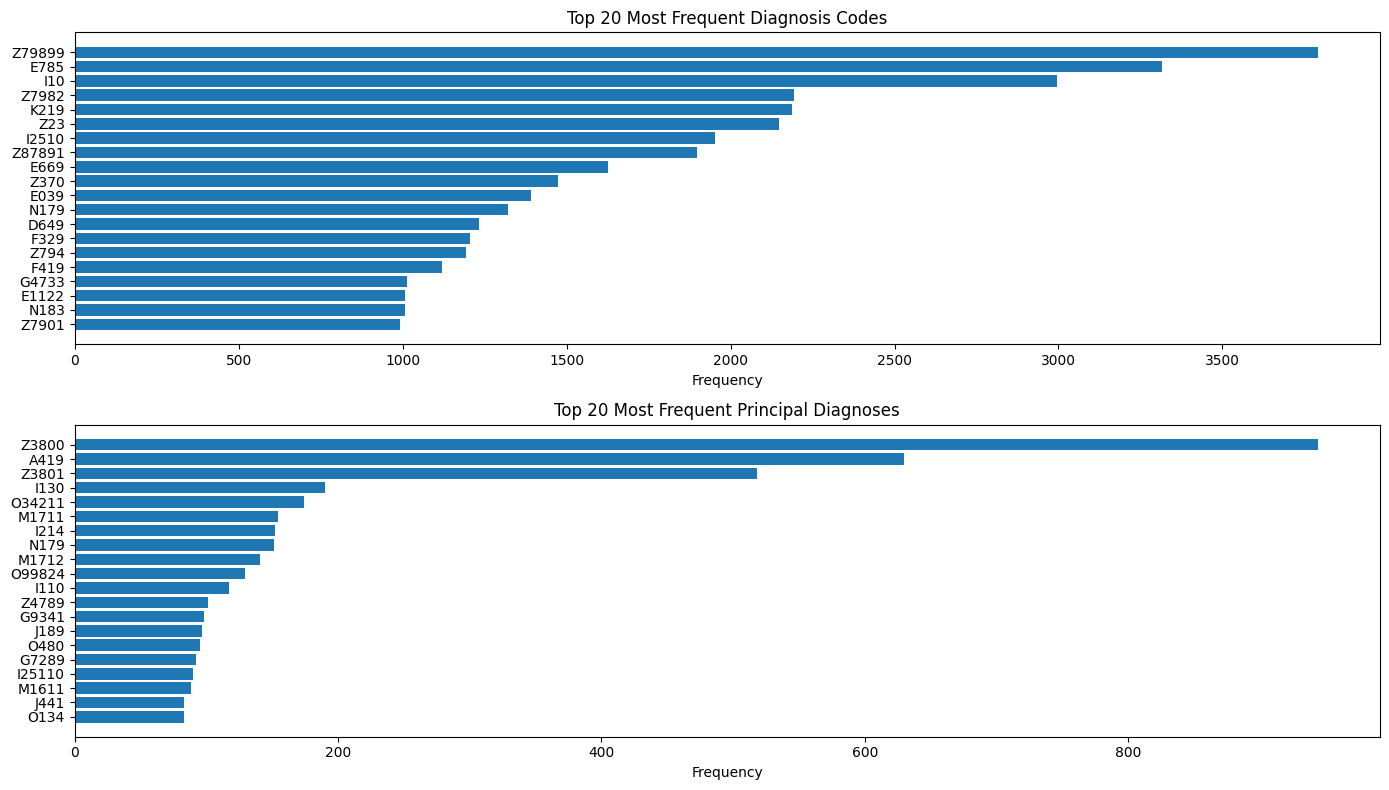

In [14]:
# Visualization
plt.figure(figsize=(14, 8))

# Top 20 overall
plt.subplot(2, 1, 1)
top_20_codes = [code for code, _ in top_diagnoses[:20]]
top_20_counts = [count for _, count in top_diagnoses[:20]]
plt.barh(range(len(top_20_codes)), top_20_counts)
plt.yticks(range(len(top_20_codes)), top_20_codes)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Diagnosis Codes')
plt.gca().invert_yaxis()

# Top 20 principal diagnoses only
plt.subplot(2, 1, 2)
princ_top_20 = df['PRINC_DIAG_CODE'].value_counts().head(20)
plt.barh(range(len(princ_top_20)), princ_top_20.values)
plt.yticks(range(len(princ_top_20)), princ_top_20.index)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Principal Diagnoses')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The most frequent overall diagnoses bar chart displays the most commonly occurring diagnosis codes across all 25 diagnosis positions in the dataset. Z79899 (long-term use of other medications) is the highest diagnoses, with almost 4000 occurences, followed by E785 (hyperlipidemia), I10 (essential hypertension), and Z7982 (long-term use of aspirin). The prevalence of chronic condition codes and medication management codes are an indicator that they chronic conditions frequently co-occur with the primary reason for hospitalization.

The principal diagnoses chart shows the primary reason for admission. Z3800 (single liveborn infant) is by far the most common principal diagnosis with over 1,200 occurrences, suggesting significant obstetric/maternity volume. This is followed by A419 (sepsis), Z3801 (single liveborn infant, born outside hospital), and I130 (hypertensive heart and chronic kidney disease). The distribution is notably different from all-position diagnoses, with more acute conditions appearing as primary admission reasons, while chronic conditions dominate secondary positions.

In [15]:
# Generate co-occurrence matrix and visualize heatmap
pair_counts = {}

for idx, row in df.iterrows():
  encounter_diagnoses = []
  for col in existing_diag_cols:
    if pd.notna(row[col]) and row[col] in top_20_codes:
      encounter_diagnoses.append(row[col])
  for diag1, diag2 in combinations(sorted(set(encounter_diagnoses)), 2):
    pair = (diag1, diag2)
    pair_counts[pair] = pair_counts.get(pair, 0) + 1

print(f"\n\nTop 20 Co-occurring Diagnosis Pairs:")
print(f"{'Rank':<6}{'Diagnosis 1':<15}{'Diagnosis 2':<15}{'Count':<10}")

sorted_pairs = sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)
for i, ((diag1, diag2), count) in enumerate(sorted_pairs[:20], 1):
  print(f"{i:<6}{diag1:<15}{diag2:<15}{count:<10}")

cooccur_matrix = pd.DataFrame(0, index=top_20_codes, columns=top_20_codes)

for (diag1, diag2), count in pair_counts.items():
  cooccur_matrix.loc[diag1, diag2] = count
  cooccur_matrix.loc[diag2, diag1] = count

# summary stats
print(f"\n\nSummary Statistics:")
print(f"Total unique pairs found: {len(pair_counts)}")
print(f"Most common pair: {sorted_pairs[0][0]} with {sorted_pairs[0][1]} co-occurrences")
print(f"Average co-occurrences per pair: {np.mean(list(pair_counts.values())):.1f}")




Top 20 Co-occurring Diagnosis Pairs:
Rank  Diagnosis 1    Diagnosis 2    Count     
1     Z7982          Z79899         1520      
2     E785           Z79899         1465      
3     E785           I10            1409      
4     I10            Z79899         1401      
5     E785           I2510          1179      
6     E785           Z7982          1135      
7     E785           K219           1071      
8     Z79899         Z87891         1048      
9     K219           Z79899         1002      
10    I10            Z7982          866       
11    I2510          Z79899         849       
12    E669           Z79899         821       
13    I10            K219           806       
14    E785           Z87891         782       
15    I2510          Z7982          776       
16    Z7982          Z87891         713       
17    N179           Z79899         697       
18    E039           E785           696       
19    E669           E785           688       
20    E785           

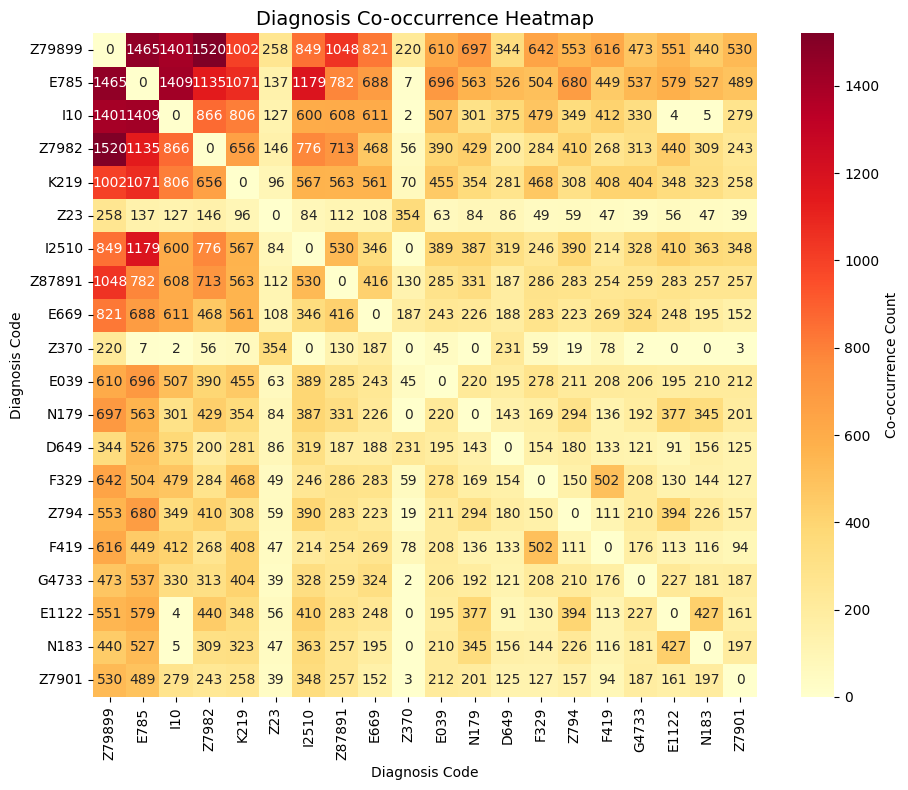

In [17]:
# visualize as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cooccur_matrix,
            annot=True,
            fmt='g',
            cmap='YlOrRd',
            square=True,
            cbar_kws={'label': 'Co-occurrence Count'})

plt.title('Diagnosis Co-occurrence Heatmap', fontsize=14)
plt.xlabel('Diagnosis Code')
plt.ylabel('Diagnosis Code')
plt.tight_layout()
plt.show()

This symmetric matrix visualizes how frequently pairs of the top 20 diagnosis codes appear together in the same encounter. These were a few observations I made from the heat map:

* Z79899 shows very high co-occurrence with multiple codes, particularly with chronic condition codes

* Medication codes (Z79899, Z7982, Z87891) cluster together, which can indicate patients on multiple long-term therapies

* The intensity pattern suggests certain diagnosis combinations are almost always co-occurring


## Initial Insights and Direction

**Observation:**
* The majority of encounters have relatively sparse diagnosis baskets, but there's significant heterogeneity with ~10% of encounters having 14+ diagnoses, and substantial truncation at 25 diagnoses.
* Chronic condition codes dominate co-occurrence patterns, while acute conditions appear primarily as principal diagnoses but less frequently in co-occurrence clusters.

**Hypotheses:**
* Standard support thresholds may capture only chronic disease combinations while missing clinically meaningful acute diagnosis patterns
* Sequential patterns in returning patients may reveal disease progression trajectories that static itemset mining cannot detect.

**Research Questions**
* How do optimal support thresholds differ between chronic versus acute diagnosis patterns, and what hybrid approaches could capture both?
* What sequential patterns emerge in returning patients' diagnosis codes that predict readmission or disease progression?
* Do diagnosis co-occurrence patterns differ significantly between principal diagnosis categories (e.g., maternity vs. cardiovascular vs. sepsis admissions)?

## Github Portfolio Building

https://github.com/stellasdong/676_project.git

## Collaboration Declaration
On my honor, I declare the following resources:
1. Collaborators:
-

2. Web Sources:
- Texas Hospital Inpatient Discharge Public Use Data File, 2019. Texas Department of State Health Services, Center for Health
Statistics, Austin, Texas. https://www.dshs.texas.gov/center-health-statistics/texas-health-care-information-collection/download-and-purchase-data/texas-inpatient-public-use-data-file-pudf/public-use-data-File-pudf-inpatient-free-download
- Centers for Medicare & Medicaid Services. (2025). 2026 Health Insurance Exchange Public Use Files
(Rates PUF). Retrieved from
http://www.cms.gov/CCIIO/Resources/Data-Resources/marketplace-puf.html
- NC Voter Registry: https://www.ncsbe.gov/results-data/voter-history-data
- Reporting Status of Texas Hospitals, 2024: https://www.dshs.texas.gov/sites/default/files/thcic/hospitals/inpatientstatusreport4q2024.pdf
- converting ICD-10-CM codes: https://www.icd10data.com/ICD10CM/Codes
- Texas Inpatient PUDF Data Dictionary: https://dshs-wcms-internet.s3.dualstack.us-gov-west-1.amazonaws.com/THCIC/InpatientFreePUDF/InpatientDataDictionary1Q2019.pdf

3. AI Tools:
- ChatGPT: I prompted GPT to write a code snippet to visualize a basket distribution for number of diagnoses per patient encounter. I also prompted ChatGPT for what would be the best way to display the histogram for the most frequent diagnoses codes.

4. Citations:
-